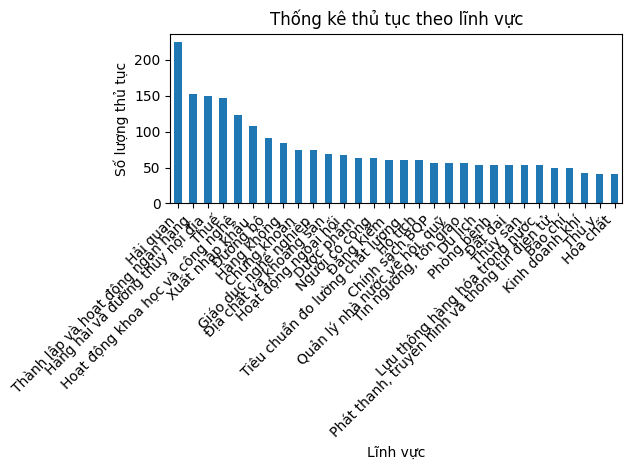

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc file Excel
df = pd.read_excel("danh-sach-tthc-2026-04-22-04-23.xlsx", engine="openpyxl")

# Thống kê số lượng theo "Lĩnh vực"
counts = df['Lĩnh vực'].value_counts().head(30)

# Vẽ biểu đồ cột
plt.figure()
counts.plot(kind='bar')

plt.xlabel("Lĩnh vực")
plt.ylabel("Số lượng thủ tục")
plt.title("Thống kê thủ tục theo lĩnh vực")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

In [24]:
import pandas as pd

# Đọc file Excel
df = pd.read_excel("danh-sach-tthc-2026-04-17-02-35.xlsx", engine="openpyxl")

# Thống kê top 30 lĩnh vực
counts = df['Lĩnh vực'].value_counts().head(150)

# In ra đầy đủ
print(counts.to_string())

Lĩnh vực
Hải quan                                                                               225
Thành lập và hoạt động ngân hàng                                                       152
Thuế                                                                                   147
Xuất nhập khẩu                                                                         108
Hàng không                                                                              78
Chứng khoán                                                                             75
Hàng hải và đường thủy nội địa                                                          69
Hoạt động ngoại hối                                                                     68
Dược phẩm                                                                               63
Hộ tịch                                                                                 57
Chính sách BQP                                                                   

In [17]:
filtered = df[df['Lĩnh vực'] == 'Đăng ký, quản lý cư trú']
pd.set_option('display.max_colwidth', None)
filtered[["Mã số", "Tên"]]

,Mã số,Tên


In [3]:
import pandas as pd
from elasticsearch import Elasticsearch, helpers
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

d:\capstone-project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
# ============================================================
# CẤU HÌNH
# ============================================================
ES_URL        = "https://my-elasticsearch-project-d2c390.es.asia-southeast1.gcp.elastic.cloud:443"
ES_INDEX      = "thu_tuc"
EXCEL_FILE    = "danh-sach-tthc-2026-04-22-04-23.xlsx"
EMBED_MODEL   = "keepitreal/vietnamese-sbert"  # Hoặc: "intfloat/multilingual-e5-base"
VECTOR_DIM    = 768
BATCH_SIZE    = 64
RRF_RANK_K    = 60   # Hằng số RRF, thường dùng 60
RRF_TOP_N     = 10   # Số kết quả trả về sau khi merge

# ============================================================
# 1. KẾT NỐI ELASTICSEARCH
# ============================================================
def get_es_client() -> Elasticsearch:
    es = Elasticsearch(
        ES_URL,
        api_key="OUJRRnM1MEJfY0Rfc2drbUl6cE46cXFybG1vcWk2LWEyVTJseVFHZ2x4UQ=="
    )
    if not es.ping():
        raise ConnectionError(f"Không thể kết nối Elasticsearch tại {ES_URL}")
    print(f"✅ Kết nối Elasticsearch thành công: {ES_URL}")
    return es

get_es_client()


✅ Kết nối Elasticsearch thành công: https://my-elasticsearch-project-d2c390.es.asia-southeast1.gcp.elastic.cloud:443


<Elasticsearch(['https://my-elasticsearch-project-d2c390.es.asia-southeast1.gcp.elastic.cloud:443'])>

In [9]:
# ============================================================
# 2. TẠO INDEX VỚI MAPPING HỖ TRỢ VECTOR + TEXT
# ============================================================
INDEX_MAPPING = {
    "settings": {
        "analysis": {
            "analyzer": {
                "vietnamese_analyzer": {
                    "type": "custom",
                    "tokenizer": "standard",
                    "filter": ["lowercase", "asciifolding"]
                }
            }
        }
    },
    "mappings": {
        "properties": {
            "ma_so":              {"type": "keyword"},
            "ten":                {"type": "text", "analyzer": "vietnamese_analyzer"},
            "co_quan_ban_hanh":   {"type": "text", "analyzer": "vietnamese_analyzer",
                                   "fields": {"keyword": {"type": "keyword"}}},
            "co_quan_thuc_hien":  {"type": "text", "analyzer": "vietnamese_analyzer",
                                   "fields": {"keyword": {"type": "keyword"}}},
            "linh_vuc":           {"type": "text", "analyzer": "vietnamese_analyzer",
                                   "fields": {"keyword": {"type": "keyword"}}},
            # Trường full text để tìm kiếm lexical tổng hợp
            "full_text":          {"type": "text", "analyzer": "vietnamese_analyzer"},
            # Trường vector để tìm kiếm semantic
            "embedding":          {"type": "dense_vector", "dims": VECTOR_DIM,
                                   "index": True, "similarity": "cosine"}
        }
    }
}

def create_index(es: Elasticsearch):
    if es.indices.exists(index=ES_INDEX):
        print(f"⚠️  Index '{ES_INDEX}' đã tồn tại, bỏ qua bước tạo.")
        return
    es.indices.create(index=ES_INDEX, body=INDEX_MAPPING)
    print(f"✅ Tạo index '{ES_INDEX}' thành công.")

In [10]:
# ============================================================
# 3. ĐỌC EXCEL VÀ CHUẨN HÓA
# ============================================================
COLUMN_MAP = {
    0: "ma_so",
    1: "ten",
    2: "co_quan_ban_hanh",
    3: "co_quan_thuc_hien",
    4: "linh_vuc"
}

def load_excel(path: str) -> pd.DataFrame:
    df = pd.read_excel(path, dtype=str)
    df.columns = [COLUMN_MAP.get(i, col) for i, col in enumerate(df.columns)]
    df = df.fillna("")
    df["full_text"] = (
        df["ten"] + " " +
        df["co_quan_ban_hanh"] + " " +
        df["co_quan_thuc_hien"] + " " +
        df["linh_vuc"]
    ).str.strip()
    print(f"✅ Đọc {len(df)} dòng từ '{path}'")
    return df

In [11]:
# ============================================================
# 4. TẠO EMBEDDING THEO BATCH
# ============================================================
def encode_texts(model: SentenceTransformer, texts: list[str]) -> list[list[float]]:
    embeddings = model.encode(
        texts,
        batch_size=BATCH_SIZE,
        show_progress_bar=True,
        normalize_embeddings=True  # Cosine similarity cần normalize
    )
    return embeddings.tolist()

In [12]:
# ============================================================
# 5. INDEX DỮ LIỆU VÀO ELASTICSEARCH
# ============================================================
def index_documents(es: Elasticsearch, df: pd.DataFrame, model: SentenceTransformer):
    print("🔄 Đang tạo embeddings...")
    embeddings = encode_texts(model, df["full_text"].tolist())

    def generate_actions():
        for i, (_, row) in enumerate(df.iterrows()):
            yield {
                "_index": ES_INDEX,
                "_id": row["ma_so"] if row["ma_so"] else str(i),
                "_source": {
                    "ma_so":             row["ma_so"],
                    "ten":               row["ten"],
                    "co_quan_ban_hanh":  row["co_quan_ban_hanh"],
                    "co_quan_thuc_hien": row["co_quan_thuc_hien"],
                    "linh_vuc":          row["linh_vuc"],
                    "full_text":         row["full_text"],
                    "embedding":         embeddings[i]
                }
            }

    print("🔄 Đang index vào Elasticsearch...")
    success, failed = helpers.bulk(es, generate_actions(), chunk_size=200, raise_on_error=False)
    print(f"✅ Index xong: {success} thành công, {failed} thất bại.")

In [13]:
# ============================================================
# 6. HYBRID SEARCH: LEXICAL + SEMANTIC → RRF
# ============================================================
def hybrid_search(
    es: Elasticsearch,
    model: SentenceTransformer,
    query: str,
    top_n: int = RRF_TOP_N,
    rrf_k: int = RRF_RANK_K
) -> list[dict]:
    """
    Bước 1: Lexical search (BM25) lấy top-100
    Bước 2: Semantic search (kNN vector) lấy top-100
    Bước 3: RRF merge 2 danh sách → top_n kết quả cuối
    """
    fetch_size = 100

    # --- Lexical search (BM25) ---
    lexical_query = {
        "size": fetch_size,
        "_source": ["ma_so", "ten", "co_quan_ban_hanh", "co_quan_thuc_hien", "linh_vuc"],
        "query": {
            "multi_match": {
                "query": query,
                "fields": [
                    "ten^3",
                    "co_quan_ban_hanh^1.5",
                    "co_quan_thuc_hien^1.5",
                    "linh_vuc^2",
                    "full_text"
                ],
                "type": "best_fields",
                "fuzziness": "AUTO"
            }
        }
    }
    lexical_resp = es.search(index=ES_INDEX, body=lexical_query)
    lexical_hits  = lexical_resp["hits"]["hits"]

    # --- Semantic search (kNN) ---
    query_vec = model.encode([query], normalize_embeddings=True)[0].tolist()
    semantic_query = {
        "size": fetch_size,
        "_source": ["ma_so", "ten", "co_quan_ban_hanh", "co_quan_thuc_hien", "linh_vuc"],
        "knn": {
            "field": "embedding",
            "query_vector": query_vec,
            "k": fetch_size,
            "num_candidates": fetch_size * 5
        }
    }
    semantic_resp = es.search(index=ES_INDEX, body=semantic_query)
    semantic_hits  = semantic_resp["hits"]["hits"]

    # --- RRF Fusion ---
    rrf_scores: dict[str, float] = {}
    doc_store:  dict[str, dict]  = {}

    def apply_rrf(hits: list[dict], rank_k: int):
        for rank, hit in enumerate(hits, start=1):
            doc_id = hit["_id"]
            rrf_scores[doc_id] = rrf_scores.get(doc_id, 0.0) + 1.0 / (rank_k + rank)
            if doc_id not in doc_store:
                doc_store[doc_id] = hit["_source"]

    apply_rrf(lexical_hits,  rrf_k)
    apply_rrf(semantic_hits, rrf_k)

    # Sắp xếp theo RRF score giảm dần
    ranked = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

    results = []
    for doc_id, score in ranked:
        results.append({
            "id":               doc_id,
            "rrf_score":        round(score, 6),
            **doc_store[doc_id]
        })
    return results

In [21]:
def lexical_search(
    es: Elasticsearch,
    query: str,
    top_n: int = RRF_TOP_N,
) -> list[dict]:
    lexical_query = {
        "size": top_n,
        "_source": ["ma_so", "ten", "co_quan_ban_hanh", "co_quan_thuc_hien", "linh_vuc"],
        "query": {
            "multi_match": {
                "query": query,
                "fields": [
                    "ten^3",
                    "co_quan_ban_hanh^1.5",
                    "co_quan_thuc_hien^1.5",
                    "linh_vuc^2",
                    "full_text"
                ],
                "type": "best_fields",
                "fuzziness": "AUTO"
            }
        }
    }

    resp = es.search(index=ES_INDEX, body=lexical_query)

    results = []
    for hit in resp["hits"]["hits"]:
        results.append({
            "id": hit["_id"],
            "bm25_score": round(hit["_score"], 6),
            **hit["_source"]
        })
    return results

In [14]:
# ============================================================
# 7. HIỂN THỊ KẾT QUẢ
# ============================================================
def print_results(results: list[dict], query: str):
    print(f"\n{'='*65}")
    print(f"🔍 Query: \"{query}\"")
    print(f"{'='*65}")
    for i, r in enumerate(results, 1):
        print(f"\n[{i}] ID: {r['id']}  |  RRF Score: {r['rrf_score']}")
        print(f"    Tên              : {r.get('ten','')}")
        print(f"    Cơ quan ban hành : {r.get('co_quan_ban_hanh','')}")
        print(f"    Cơ quan thực hiện: {r.get('co_quan_thuc_hien','')}")
        print(f"    Lĩnh vực         : {r.get('linh_vuc','')}")
    print(f"\n{'='*65}\n")

In [15]:
# ============================================================
# 8. MAIN
# ============================================================
def main():
    es    = get_es_client()
    model = SentenceTransformer(EMBED_MODEL)
    print(f"✅ Load model '{EMBED_MODEL}' thành công (dim={VECTOR_DIM})")

    # Tạo index (bỏ qua nếu đã tồn tại)
    create_index(es)

    # Index dữ liệu (comment dòng này nếu đã index rồi)
    df = load_excel(EXCEL_FILE)
    index_documents(es, df, model)

    # Demo search
    sample_queries = [
        "thủ tục hành chính thuế",
        "giấy phép xây dựng",
        "bộ tài nguyên môi trường",
    ]
    for q in sample_queries:
        results = hybrid_search(es, model, q, top_n=5)
        print_results(results, q)


if __name__ == "__main__":
    main()

✅ Kết nối Elasticsearch thành công: https://my-elasticsearch-project-d2c390.es.asia-southeast1.gcp.elastic.cloud:443


d:\capstone-project\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\trand\.cache\huggingface\hub\models--keepitreal--vietnamese-sbert. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6278.24it/s]
RobertaModel LOAD REPORT from: keepitreal/vietn

✅ Load model 'keepitreal/vietnamese-sbert' thành công (dim=768)
✅ Tạo index 'thu_tuc' thành công.
✅ Đọc 4858 dòng từ 'danh-sach-tthc-2026-04-22-04-23.xlsx'
🔄 Đang tạo embeddings...


Batches: 100%|██████████| 76/76 [10:02<00:00,  7.92s/it]


🔄 Đang index vào Elasticsearch...
✅ Index xong: 4858 thành công, [] thất bại.

🔍 Query: "thủ tục hành chính thuế"

[1] ID: 3.000051  |  RRF Score: 0.016393
    Tên              : Thế chấp một phần tài sản hình thành từ nguồn vốn được Chính phủ bảo lãnh cho bên thứ ba
    Cơ quan ban hành : Bộ Tài chính
    Cơ quan thực hiện: Bộ Tài chính
    Lĩnh vực         : Quản lý nợ

[2] ID: 1.007022  |  RRF Score: 0.016393
    Tên              : Khai thuế giá trị gia tăng đối với phương pháp trực tiếp trên doanh thu
    Cơ quan ban hành : Bộ Tài chính
    Cơ quan thực hiện: Cục Thuế - Bộ tài chính
Thuế tỉnh, thành phố
Thuế cơ sở
    Lĩnh vực         : Thuế

[3] ID: 1.008567  |  RRF Score: 0.016257
    Tên              : Thủ tục đăng ký điều chỉnh, chấm dứt việc bán hàng hoàn thuế giá trị gia tăng
    Cơ quan ban hành : Bộ Tài chính
    Cơ quan thực hiện: Cục Thuế - Bộ tài chính
Thuế tỉnh, thành phố
    Lĩnh vực         : Thuế

[4] ID:  1.014489  |  RRF Score: 0.016129
    Tên              : Thủ t

In [16]:
# ============================================================
# 8. MAIN
# ============================================================
def main():
    es    = get_es_client()
    model = SentenceTransformer(EMBED_MODEL)
    print(f"✅ Load model '{EMBED_MODEL}' thành công (dim={VECTOR_DIM})")

    # Demo search
    sample_queries = [
        "Tôi muốn mở quán cà phê thì làm thủ tục gì?",
        "Tôi và vợ vào miền Nam làm việc thì cần làm thủ tục gì?",
        "Thủ tục cấp lại căn cước công dân ở cấp tỉnh và trung ương khác nhau thế nào?",
    ]
    for q in sample_queries:
        results = hybrid_search(es, model, q, top_n=5)
        print_results(results, q)


if __name__ == "__main__":
    main()

✅ Kết nối Elasticsearch thành công: https://my-elasticsearch-project-d2c390.es.asia-southeast1.gcp.elastic.cloud:443


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12758.39it/s]
RobertaModel LOAD REPORT from: keepitreal/vietnamese-sbert
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Load model 'keepitreal/vietnamese-sbert' thành công (dim=768)

🔍 Query: "Tôi muốn mở quán cà phê thì làm thủ tục gì?"

[1] ID: 1.001815  |  RRF Score: 0.021667
    Tên              : Thủ tục cấp Giấy phép đối với tổ chức tài chính vi mô
    Cơ quan ban hành : Ngân hàng Nhà nước Việt Nam
    Cơ quan thực hiện: Ngân hàng Nhà nước Việt Nam
    Lĩnh vực         : Thành lập và hoạt động ngân hàng

[2] ID: 1.014697  |  RRF Score: 0.016393
    Tên              : Thủ tục đăng cai tổ chức giải thi đấu từng môn thể thao cấp khu vực,  châu lục, thế giới tổ chức tại Việt Nam cho người khuyết tật; giải thi đấu thể thao quần chúng cấp quốc gia
    Cơ quan ban hành : Bộ Văn hóa, Thể thao và Du lịch
    Cơ quan thực hiện: Cục Thể dục thể thao - Bộ Văn hóa - Thể thao và Du lịch
    Lĩnh vực         : Thể dục thể thao

[3] ID: 3.000040  |  RRF Score: 0.016393
    Tên              : Thủ tục cấp Giấy chứng nhận đủ điều kiện kinh doanh đặt cược bóng đá quốc tế
    Cơ quan ban hành : Bộ Tài chính
    Cơ q

In [17]:
es    = get_es_client()
model = SentenceTransformer(EMBED_MODEL)
print(f"✅ Load model '{EMBED_MODEL}' thành công (dim={VECTOR_DIM})")

✅ Kết nối Elasticsearch thành công: https://my-elasticsearch-project-d2c390.es.asia-southeast1.gcp.elastic.cloud:443


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9462.80it/s]
RobertaModel LOAD REPORT from: keepitreal/vietnamese-sbert
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Load model 'keepitreal/vietnamese-sbert' thành công (dim=768)


In [26]:
import json
def main():


    # Demo search
    sample_queries = [
        "Tôi muốn làm thủ tục đăng kí khai sinh thì làm như nào?",
    ]
    for q in sample_queries:
        results = lexical_search(es, q)
        print(json.dumps(results, ensure_ascii=False, indent=2))


if __name__ == "__main__":
    main()

[
  {
    "id": "1.009107",
    "bm25_score": 70.70856,
    "ma_so": "1.009107",
    "ten": "Thủ tục tạm dừng hoạt động/ hoạt động trở lại của địa điểm làm thủ tục hải quan tại cảng xuất khẩu, nhập khẩu hàng hóa được thành lập trong nội địa",
    "co_quan_ban_hanh": "Bộ Tài chính",
    "co_quan_thuc_hien": "Cục Hải quan - Bộ tài chính",
    "linh_vuc": "Hải quan"
  },
  {
    "id": "1.014168",
    "bm25_score": 69.18136,
    "ma_so": "1.014168",
    "ten": "HƯỞNG CHẾ ĐỘ THAI SẢN ĐỐI VỚI LAO ĐỘNG NAM KHI VỢ SINH CON, NGƯỜI CHỒNG CỦA LAO ĐỘNG NỮ NHỜ MANG THAI HỘ, NGƯỜI CHỒNG CỦA LAO ĐỘNG NỮ MANG THAI HỘ KHI VỢ SINH CON",
    "co_quan_ban_hanh": "Bộ Nội vụ",
    "co_quan_thuc_hien": "Bảo hiểm xã hội tỉnh",
    "linh_vuc": "Bảo hiểm xã hội"
  },
  {
    "id": "1.007833",
    "bm25_score": 68.53587,
    "ma_so": "1.007833",
    "ten": "Thủ tục khai báo giá tạm tính đối với hàng hóa xuất khẩu, nhập khẩu; khai báo khoản phí bản quyền, giấy phép; các khoản tiền mà người nhập khẩu phải trả từ s